[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Clases/Clase20260507.ipynb)

In [9]:
!pip install pymcel celluloid -q

In [38]:
import numpy as np
import pymcel as pc
import matplotlib.pyplot as plt
from celluloid import Camera
from scipy.integrate import solve_ivp
deg = np.pi/180
rad = 180/np.pi

In [39]:
def edm_pendulo_simple(t, Ys, g, L):
    theta, u = Ys
    dtheta_dt = u
    du_dt = -g/L*np.sin(theta)
    return [dtheta_dt, du_dt]

In [40]:
edm_pendulo_simple(0, [np.pi/2, 0], 9.8, 1)

[0, np.float64(-9.8)]

In [65]:
ts = np.linspace(0,10,100)
Y0s = [120*deg,200*deg]
g = 9.8 #m/s^2
L = 1 #m
sol = solve_ivp(
    edm_pendulo_simple,
    [ts[0], ts[-1]],
    Y0s, args=(g, L),
    t_eval=ts)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 2.094e+00  2.407e+00 ...  3.976e+01  4.011e+01]
            [ 3.491e+00  2.728e+00 ...  3.813e+00  3.042e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 266
     njev: 0
      nlu: 0

In [66]:
thetas = sol.y[0]
us = sol.y[1]

In [67]:
# Coordenadas

xs = L*np.sin(thetas)
ys = -L*np.cos(thetas)

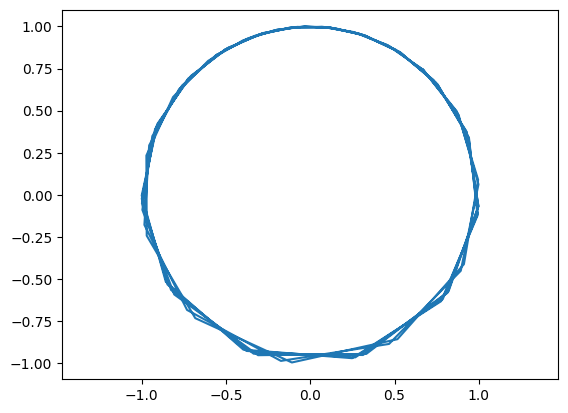

In [68]:
plt.plot(xs, ys)
plt.axis("equal");

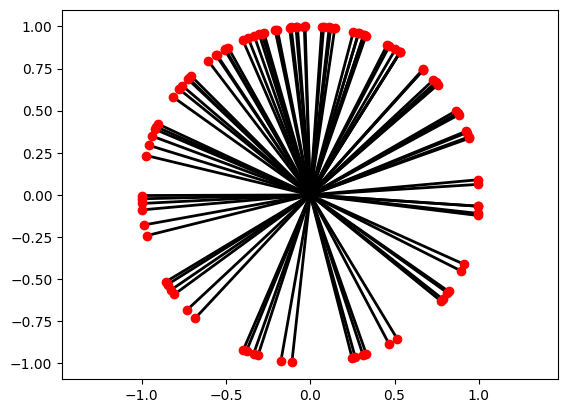

In [69]:
fig = plt.figure()
camera = Camera(fig)
for i, t in enumerate(ts):
    plt.plot([0,xs[i]],[0,ys[i]], "k-",lw=2)
    plt.plot(xs[i], ys[i], "ro")
    camera.snap()
plt.axis("equal");

In [70]:
from IPython.display import HTML
animation = camera.animate()
HTML(animation.to_jshtml())

* Número de particulas: $N=1$
* Coordenadas: $3N = (x, y, z)$
* Restricciones $k=1 \implies z=0$
* Grados de libertad $M=3N-k = 2$
* Coordenadas generalizadas: $(q_1,q_2)=(x, y),(\theta,e)$
* Reglas de transaformación:

$x = (L+e)\sin(\theta)$

$y = -(L+e)\cos(\theta)$

$z=0$

# Tarea: Simular el péndulo cónico
* $N=1$
* $3N = 3$
* $k=1$
* $M=2$